# Projeto Original — Análise de Sentimentos com Embeddings

**Ciclo de divergência: `MODEL`.**

O projeto FMF resolve a classificação binária de sentimento em reviews do IMDB usando **TF-IDF + algoritmos clássicos de ML**. Aqui mantemos exatamente o mesmo problema, os mesmos dados e os mesmos classificadores finais, e trocamos apenas a **representação textual** — que é o nosso ponto de divergência.

Comparamos 4 representações, da mais lexical à mais semântica:

1. **TF-IDF** — reproduz o FMF (linha de base).
2. **BM25** — baseline lexical forte (TF-IDF melhorado: saturação de termo + normalização por comprimento).
3. **BGE-large-en-v1.5** — embedding denso especialista em inglês, SOTA, mas trunca em 512 tokens.
4. **BGE-M3** — embedding denso de **contexto longo (8192 tokens)**: lê a review inteira sem truncar.

Cada representação alimenta os **mesmos 4 classificadores** (SVM linear, Regressão Logística, Naive Bayes e Árvore de Decisão), isolando a variável "representação textual".

**Pergunta de pesquisa do ciclo:** ler a review inteira (BGE-M3) compensa, ou um encoder inglês mais forte vence mesmo truncando? E os embeddings densos realmente superam um bom método lexical (BM25) num dataset pequeno? O comportamento muda com classificadores mais simples (Naive Bayes, Árvore de Decisão)?


## Dependências

Execute a célula abaixo uma vez para instalar as bibliotecas necessárias (descomente se ainda não tiver instalado).

In [4]:
#!pip install pandas scikit-learn imbalanced-learn matplotlib seaborn sentence-transformers torch

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=13)
plt.rc('ytick', labelsize=13)
plt.rc('legend', fontsize=13)
plt.rc('font', size=13)

RANDOM_STATE = 42

# GET — Obtenção dos dados

Usamos o **mesmo dataset e a mesma amostragem do FMF**, garantindo que os conjuntos de treino e teste sejam idênticos (mesmo `random_state`). Assim, qualquer diferença de desempenho vem da representação textual, não dos dados.

> O arquivo `IMDB Dataset.csv` (50k reviews) deve ser baixado do [Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) e colocado na raiz do repositório ou na pasta `FMF/`. A célula abaixo procura em vários caminhos.

In [6]:
import os

CANDIDATE_PATHS = [
    'IMDB Dataset.csv',
    '../IMDB Dataset.csv',
    '../FMF/IMDB Dataset.csv',
    'FMF/IMDB Dataset.csv',
]

csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        'IMDB Dataset.csv não encontrado. Baixe do Kaggle e coloque na raiz do repositório.'
    )

df_review = pd.read_csv(csv_path)
print(f'Carregado de: {csv_path}')
df_review.head()

Carregado de: IMDB Dataset.csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Mesma amostragem desbalanceada do FMF: 9000 positivos + 1000 negativos
df_positive = df_review[df_review['sentiment'] == 'positive'][:9000]
df_negative = df_review[df_review['sentiment'] == 'negative'][:1000]
df_review_imb = pd.concat([df_positive, df_negative])

# Balanceamento por undersampling (igual ao FMF)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=0)
df_review_bal, df_review_bal['sentiment'] = rus.fit_resample(
    df_review_imb[['review']], df_review_imb['sentiment']
)
df_review_bal.value_counts('sentiment')

,count
sentiment,
negative,1000
positive,1000


In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_review_bal, test_size=0.33, random_state=RANDOM_STATE)
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

print('Treino:', train_x.shape[0], '| Teste:', test_x.shape[0])
print(train_y.value_counts())

Treino: 1340 | Teste: 660
sentiment
negative    675
positive    665
Name: count, dtype: int64


In [9]:
# Estatística de comprimento das reviews — motiva o uso de modelos de contexto longo
lengths = train_x.str.split().str.len()
print(f'Palavras por review (treino): média={lengths.mean():.0f}, '
      f'mediana={lengths.median():.0f}, p95={lengths.quantile(0.95):.0f}, máx={lengths.max()}')
print(f'% de reviews com >512 palavras: {(lengths > 512).mean() * 100:.1f}%')

Palavras por review (treino): média=230, mediana=173, p95=570, máx=1011
% de reviews com >512 palavras: 7.5%


# Função de avaliação comum

Para uma comparação justa, todas as representações usam o mesmo procedimento: treinar **quatro classificadores** (SVM linear, Regressão Logística, Naive Bayes Gaussiano e Árvore de Decisão) sobre os vetores e avaliar com acurácia e F1 macro. Os resultados são acumulados em `RESULTS`.

**Nota técnica:** `GaussianNB` exige arrays densos. Matrizes esparsas (TF-IDF, BM25) são convertidas automaticamente com `.toarray()` antes de alimentar o Naive Bayes; os demais classificadores aceitam a representação original (esparsa ou densa).


In [10]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import scipy.sparse as sp

LABELS = ['positive', 'negative']
RESULTS = []


def evaluate_representation(name, X_train, X_test, y_train=train_y, y_test=test_y, verbose=True):
    """Treina SVM linear, Regressão Logística, Naive Bayes e Árvore de Decisão e registra as métricas.

    GaussianNB requer arrays densos: matrizes esparsas são convertidas internamente.
    """
    # GaussianNB exige arrays densos; detectamos e convertemos matrizes esparsas
    is_sparse = sp.issparse(X_train)
    X_tr_dense = X_train.toarray() if is_sparse else X_train
    X_te_dense = X_test.toarray()  if is_sparse else X_test

    # (modelo, X_treino, X_teste)
    models = {
        'SVM (linear)':   (SVC(kernel='linear', C=1),                             X_train,    X_test),
        'LogReg':         (LogisticRegression(max_iter=1000),                      X_train,    X_test),
        'Naive Bayes':    (GaussianNB(),                                            X_tr_dense, X_te_dense),
        'Decision Tree':  (DecisionTreeClassifier(random_state=RANDOM_STATE),      X_train,    X_test),
    }
    fitted = {}
    for model_name, (model, X_tr, X_te) in models.items():
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        acc      = accuracy_score(y_test, pred)
        f1_pos, f1_neg = f1_score(y_test, pred, labels=LABELS, average=None)
        f1_macro = f1_score(y_test, pred, labels=LABELS, average='macro')
        RESULTS.append({
            'Representação': name,
            'Classificador':  model_name,
            'Acurácia':       acc,
            'F1 (pos)':       f1_pos,
            'F1 (neg)':       f1_neg,
            'F1 macro':       f1_macro,
        })
        if verbose:
            print(f'\n=== {name} — {model_name} ===')
            print(f'Acurácia: {acc:.4f} | F1 macro: {f1_macro:.4f}')
            print(classification_report(y_test, pred, labels=LABELS))
        fitted[model_name] = model
    return fitted


# Representação 1 — TF-IDF (reprodução do FMF)

Linha de base: o mesmo `TfidfVectorizer` do projeto FMF.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_train = tfidf.fit_transform(train_x)
tfidf_test = tfidf.transform(test_x)
print('Matriz TF-IDF:', tfidf_train.shape)

evaluate_representation('TF-IDF', tfidf_train, tfidf_test)

Matriz TF-IDF: (1340, 20625)

=== TF-IDF — SVM (linear) ===
Acurácia: 0.8409 | F1 macro: 0.8407
              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660


=== TF-IDF — LogReg ===
Acurácia: 0.8303 | F1 macro: 0.8299
              precision    recall  f1-score   support

    positive       0.81      0.87      0.84       335
    negative       0.85      0.79      0.82       325

    accuracy                           0.83       660
   macro avg       0.83      0.83      0.83       660
weighted avg       0.83      0.83      0.83       660


=== TF-IDF — Naive Bayes ===
Acurácia: 0.6348 | F1 macro: 0.6319
              precision    recall  f1-score   support

    positive       0.62      0.71      0.66       335
    negative  

{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000),
 'Naive Bayes': GaussianNB(),
 'Decision Tree': DecisionTreeClassifier(random_state=42)}

# Representação 2 — BM25 (baseline lexical forte)

BM25 é uma evolução do TF-IDF: além da frequência inversa de documento (IDF), aplica **saturação de termo** (com o parâmetro `k1`, frequências altas param de crescer linearmente) e **normalização por comprimento do documento** (com `b`). É o padrão de mercado em busca textual (ex.: Lucene/Elasticsearch).

Como o `scikit-learn` não traz BM25, implementamos um vetorizador BM25 compatível com a API `fit`/`transform`, reaproveitando a contagem de termos do `CountVectorizer`. O resultado é uma matriz esparsa documento-termo pronta para os mesmos classificadores.

In [12]:
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import BaseEstimator, TransformerMixin


class BM25Vectorizer(BaseEstimator, TransformerMixin):
    """Vetorizador BM25 (variante Lucene/Okapi com IDF não-negativo).

    Aprende vocabulário, IDF e comprimento médio dos documentos no fit;
    no transform produz a matriz esparsa de pesos BM25 por termo.
    """

    def __init__(self, k1=1.5, b=0.75, stop_words='english'):
        self.k1 = k1
        self.b = b
        self.stop_words = stop_words

    def fit(self, raw_documents, y=None):
        self.cv_ = CountVectorizer(stop_words=self.stop_words)
        tf = self.cv_.fit_transform(raw_documents)            # contagem de termos
        n_docs = tf.shape[0]
        df = np.bincount(tf.indices, minlength=tf.shape[1])    # nº de docs por termo
        # IDF estilo Lucene: sempre >= 0
        self.idf_ = np.log(1 + (n_docs - df + 0.5) / (df + 0.5))
        self.avgdl_ = tf.sum(axis=1).mean()
        return self

    def transform(self, raw_documents):
        tf = self.cv_.transform(raw_documents).tocsr()
        doc_len = np.asarray(tf.sum(axis=1)).ravel()
        tf = tf.tocoo()
        # denominador da fórmula BM25, por elemento não-nulo
        denom = tf.data + self.k1 * (1 - self.b + self.b * doc_len[tf.row] / self.avgdl_)
        scores = self.idf_[tf.col] * (tf.data * (self.k1 + 1)) / denom
        return sp.csr_matrix((scores, (tf.row, tf.col)), shape=tf.shape)

    def get_feature_names_out(self, input_features=None):
        return self.cv_.get_feature_names_out(input_features)

In [13]:
bm25 = BM25Vectorizer()
bm25_train = bm25.fit_transform(train_x)
bm25_test = bm25.transform(test_x)
print('Matriz BM25:', bm25_train.shape)

evaluate_representation('BM25', bm25_train, bm25_test)

Matriz BM25: (1340, 20625)

=== BM25 — SVM (linear) ===
Acurácia: 0.8455 | F1 macro: 0.8453
              precision    recall  f1-score   support

    positive       0.84      0.87      0.85       335
    negative       0.86      0.82      0.84       325

    accuracy                           0.85       660
   macro avg       0.85      0.85      0.85       660
weighted avg       0.85      0.85      0.85       660


=== BM25 — LogReg ===
Acurácia: 0.8515 | F1 macro: 0.8513
              precision    recall  f1-score   support

    positive       0.84      0.88      0.86       335
    negative       0.87      0.82      0.85       325

    accuracy                           0.85       660
   macro avg       0.85      0.85      0.85       660
weighted avg       0.85      0.85      0.85       660


=== BM25 — Naive Bayes ===
Acurácia: 0.6394 | F1 macro: 0.6351
              precision    recall  f1-score   support

    positive       0.62      0.74      0.67       335
    negative       0.6

{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000),
 'Naive Bayes': GaussianNB(),
 'Decision Tree': DecisionTreeClassifier(random_state=42)}

# Embeddings densos

A partir daqui trocamos representações esparsas (palavra-a-palavra) por **embeddings densos**: vetores contínuos que capturam significado semântico, gerados por modelos pré-treinados. Carregamos os modelos com `sentence-transformers` e usamos GPU se disponível.

> O download dos modelos (centenas de MB a ~2 GB) ocorre na primeira execução. Em CPU, codificar ~2000 textos leva alguns minutos.

In [14]:
from sentence_transformers import SentenceTransformer
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


def embed(model_name, texts, **kwargs):
    model = SentenceTransformer(model_name, device=DEVICE)
    emb = model.encode(
        list(texts),
        batch_size=8,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
        **kwargs,
    )
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return emb

Device: cuda


# Representação 3 — BGE-large-en-v1.5

Embedding denso **especialista em inglês**, no topo do MTEB para tarefas de classificação. Janela de contexto de **512 tokens** — reviews mais longas são truncadas, perdendo o final do texto.

In [15]:
bge_train = embed('BAAI/bge-large-en-v1.5', train_x)
bge_test = embed('BAAI/bge-large-en-v1.5', test_x)
print('Embeddings BGE-large-en:', bge_train.shape)

evaluate_representation('BGE-large-en-v1.5', bge_train, bge_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/168 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/83 [00:00<?, ?it/s]

Embeddings BGE-large-en: (1340, 1024)

=== BGE-large-en-v1.5 — SVM (linear) ===
Acurácia: 0.9485 | F1 macro: 0.9485
              precision    recall  f1-score   support

    positive       0.94      0.96      0.95       335
    negative       0.96      0.94      0.95       325

    accuracy                           0.95       660
   macro avg       0.95      0.95      0.95       660
weighted avg       0.95      0.95      0.95       660


=== BGE-large-en-v1.5 — LogReg ===
Acurácia: 0.9500 | F1 macro: 0.9500
              precision    recall  f1-score   support

    positive       0.95      0.96      0.95       335
    negative       0.95      0.94      0.95       325

    accuracy                           0.95       660
   macro avg       0.95      0.95      0.95       660
weighted avg       0.95      0.95      0.95       660


=== BGE-large-en-v1.5 — Naive Bayes ===
Acurácia: 0.9485 | F1 macro: 0.9484
              precision    recall  f1-score   support

    positive       0.94   

{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000),
 'Naive Bayes': GaussianNB(),
 'Decision Tree': DecisionTreeClassifier(random_state=42)}

# Representação 4 — BGE-M3

Embedding denso multilíngue com **contexto longo (8192 tokens)**: consegue ler a review **inteira** sem truncar. Este é o diferencial técnico central do nosso ciclo de divergência.

In [16]:
bgem3_train = embed('BAAI/bge-m3', train_x)
bgem3_test = embed('BAAI/bge-m3', test_x)
print('Embeddings BGE-M3:', bgem3_train.shape)

evaluate_representation('BGE-M3', bgem3_train, bgem3_test)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/168 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/83 [00:00<?, ?it/s]

Embeddings BGE-M3: (1340, 1024)

=== BGE-M3 — SVM (linear) ===
Acurácia: 0.9273 | F1 macro: 0.9271
              precision    recall  f1-score   support

    positive       0.90      0.96      0.93       335
    negative       0.96      0.89      0.92       325

    accuracy                           0.93       660
   macro avg       0.93      0.93      0.93       660
weighted avg       0.93      0.93      0.93       660


=== BGE-M3 — LogReg ===
Acurácia: 0.9303 | F1 macro: 0.9301
              precision    recall  f1-score   support

    positive       0.90      0.96      0.93       335
    negative       0.96      0.90      0.93       325

    accuracy                           0.93       660
   macro avg       0.93      0.93      0.93       660
weighted avg       0.93      0.93      0.93       660


=== BGE-M3 — Naive Bayes ===
Acurácia: 0.9121 | F1 macro: 0.9117
              precision    recall  f1-score   support

    positive       0.87      0.97      0.92       335
    negativ

{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000),
 'Naive Bayes': GaussianNB(),
 'Decision Tree': DecisionTreeClassifier(random_state=42)}

# COMMUNICATE — Comparação dos resultados

Consolidamos todas as combinações **representação × classificador** (4 × 4 = 16 experimentos) numa tabela interativa e em dois painéis visuais complementares:

- **Gráfico de barras agrupadas** — permite comparar classificadores dentro de cada representação e identificar qual par rende mais.
- **Heatmap** — visão matricial que facilita ler a linha (classificador) ou coluna (representação) de interesse.


In [17]:
REP_ORDER = ['TF-IDF', 'BM25', 'BGE-large-en-v1.5', 'BGE-M3']
CLF_ORDER = ['SVM (linear)', 'LogReg', 'Naive Bayes', 'Decision Tree']

df_results = pd.DataFrame(RESULTS)
df_results['Representação'] = pd.Categorical(df_results['Representação'], categories=REP_ORDER, ordered=True)
df_results['Classificador']  = pd.Categorical(df_results['Classificador'],  categories=CLF_ORDER,  ordered=True)
df_results = df_results.sort_values('F1 macro', ascending=False).reset_index(drop=True)

df_results.style.format({
    'Acurácia': '{:.3f}', 'F1 (pos)': '{:.3f}', 'F1 (neg)': '{:.3f}', 'F1 macro': '{:.3f}'
}).background_gradient(subset=['F1 macro', 'Acurácia'], cmap='Greens')


,Representação,Classificador,Acurácia,F1 (pos),F1 (neg),F1 macro
0,BGE-large-en-v1.5,LogReg,0.950,0.951,0.949,0.950
1,BGE-large-en-v1.5,SVM (linear),0.948,0.950,0.947,0.948
2,BGE-large-en-v1.5,Naive Bayes,0.948,0.950,0.947,0.948
3,BGE-M3,LogReg,0.930,0.934,0.927,0.930
4,BGE-M3,SVM (linear),0.927,0.931,0.924,0.927
5,BGE-M3,Naive Bayes,0.912,0.918,0.905,0.912
6,BGE-large-en-v1.5,Decision Tree,0.897,0.897,0.897,0.897
7,BM25,LogReg,0.852,0.857,0.845,0.851
8,BM25,SVM (linear),0.845,0.850,0.840,0.845
9,TF-IDF,SVM (linear),0.841,0.847,0.835,0.841


/tmp/ipykernel_10574/3581257097.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_results.pivot_table(


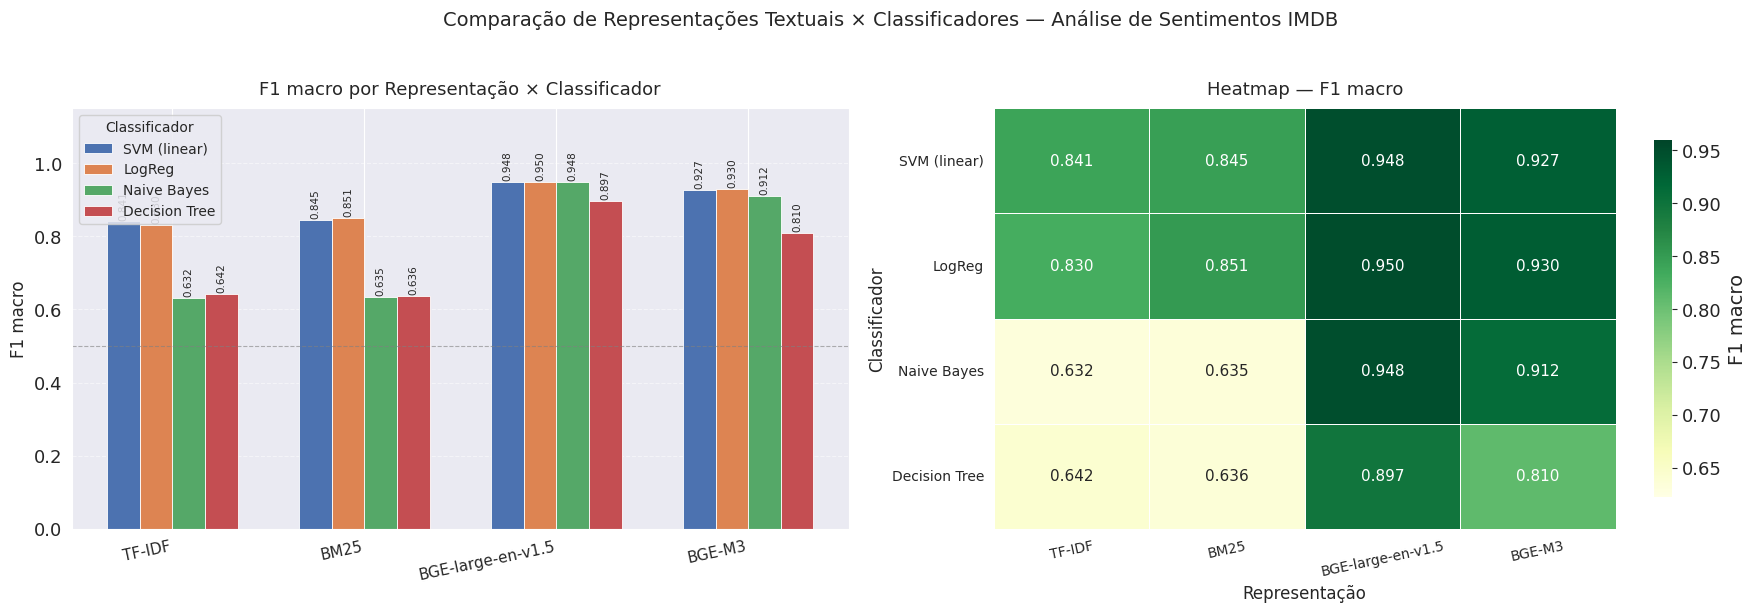


Melhor combinação: BGE-large-en-v1.5 + LogReg → F1 macro = 0.9500

Melhor classificador por representação:
    Representação Classificador  Acurácia  F1 macro
BGE-large-en-v1.5        LogReg  0.950000  0.949981
           BGE-M3        LogReg  0.930303  0.930139
             BM25        LogReg  0.851515  0.851284
           TF-IDF  SVM (linear)  0.840909  0.840680


/tmp/ipykernel_10574/3581257097.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .loc[df_results.groupby('Representação')['F1 macro'].idxmax()]


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
palette = sns.color_palette('deep', len(CLF_ORDER))

# ── Painel esquerdo: barras agrupadas (F1 macro) ─────────────────────────────
ax1 = axes[0]
n_reps = len(REP_ORDER)
n_clfs = len(CLF_ORDER)
width  = 0.17
x      = np.arange(n_reps)
offsets = np.linspace(-(n_clfs - 1) / 2, (n_clfs - 1) / 2, n_clfs) * width

for j, (clf, color) in enumerate(zip(CLF_ORDER, palette)):
    vals = [
        df_results.loc[
            (df_results['Representação'] == rep) & (df_results['Classificador'] == clf),
            'F1 macro'
        ].values[0]
        for rep in REP_ORDER
    ]
    bars = ax1.bar(
        x + offsets[j], vals, width=width,
        label=clf, color=color, edgecolor='white', linewidth=0.6
    )
    for bar, val in zip(bars, vals):
        ax1.text(
            bar.get_x() + bar.get_width() / 2, val + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90
        )

ax1.set_xticks(x)
ax1.set_xticklabels(REP_ORDER, rotation=12, ha='right', fontsize=11)
ax1.set_ylabel('F1 macro', fontsize=12)
ax1.set_title('F1 macro por Representação × Classificador', fontsize=13, pad=10)
ax1.set_ylim(0, 1.15)
ax1.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='_baseline')
ax1.legend(title='Classificador', fontsize=10, title_fontsize=10,
           loc='upper left', framealpha=0.85)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# ── Painel direito: heatmap (F1 macro) ───────────────────────────────────────
ax2 = axes[1]
pivot = df_results.pivot_table(
    index='Classificador', columns='Representação', values='F1 macro'
).loc[CLF_ORDER, REP_ORDER]

vmin = pivot.values.min() - 0.01
vmax = pivot.values.max() + 0.01

sns.heatmap(
    pivot, ax=ax2,
    annot=True, fmt='.3f', annot_kws={'size': 11},
    cmap='YlGn', linewidths=0.6, linecolor='white',
    vmin=vmin, vmax=vmax,
    cbar_kws={'label': 'F1 macro', 'shrink': 0.85}
)
ax2.set_title('Heatmap — F1 macro', fontsize=13, pad=10)
ax2.set_xlabel('Representação', fontsize=12)
ax2.set_ylabel('Classificador', fontsize=12)
ax2.tick_params(axis='x', rotation=12, labelsize=10)
ax2.tick_params(axis='y', rotation=0,  labelsize=10)

# ── Título geral e exportação ─────────────────────────────────────────────────
fig.suptitle(
    'Comparação de Representações Textuais × Classificadores — Análise de Sentimentos IMDB',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('comparacao_representacoes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Melhor combinação e melhor por representação ──────────────────────────────
best_row = df_results.loc[df_results['F1 macro'].idxmax()]
print(f"\nMelhor combinação: {best_row['Representação']} + {best_row['Classificador']}"
      f" → F1 macro = {best_row['F1 macro']:.4f}")

print('\nMelhor classificador por representação:')
best_per_rep = (
    df_results.sort_values('Representação')
    .loc[df_results.groupby('Representação')['F1 macro'].idxmax()]
    [['Representação', 'Classificador', 'Acurácia', 'F1 macro']]
    .sort_values('F1 macro', ascending=False)
)
print(best_per_rep.to_string(index=False))
